# 🏠 03_idealista — Visualización y Análisis del Mercado Inmobiliario

**TFG — Análisis y Predicción de la Migración Interna en España**



In [3]:
#============================================
# Celda 0 — Setup e imports
#============================================
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#F7F6F2', 'axes.facecolor': '#F9F8F5',
    'axes.edgecolor': '#D4D1CA', 'axes.labelcolor': '#28251D',
    'xtick.color': '#7A7974', 'ytick.color': '#7A7974',
    'text.color': '#28251D', 'grid.color': '#DCD9D5',
    'grid.linestyle': '--', 'grid.alpha': 0.6,
    'font.size': 11, 'axes.titlesize': 14,
    'axes.titleweight': 'bold', 'axes.titlepad': 12, 'figure.dpi': 120,
})

TEAL='#01696F'; TEAL2='#4F98A3'; ORANGE='#DA7101'; GOLD='#D19900'
RED='#A12C7B'; GREEN='#437A22'; BLUE='#006494'
PALETTE=[TEAL,ORANGE,BLUE,GOLD,GREEN,RED,TEAL2]

# ✅ Ruta fija a la raíz del proyecto
ROOT = Path('/workspaces/TFG_Spain-s_Migratory_Flow')
OUT  = ROOT / 'output' / 'idealista' / '03-viz'
OUT.mkdir(parents=True, exist_ok=True)

print(f'✅ Setup OK')
print(f'📁 ROOT → {ROOT}')
print(f'📁 OUT  → {OUT}')
print(f'📄 Parquet existe: {(ROOT / "output/idealista/02-clean/clean_idealista_anuncios.parquet").exists()}')

✅ Setup OK
📁 ROOT → /workspaces/TFG_Spain-s_Migratory_Flow
📁 OUT  → /workspaces/TFG_Spain-s_Migratory_Flow/output/idealista/03-viz
📄 Parquet existe: True


In [4]:
#============================================
# Celda 1 — Carga y exploración inicial
#============================================
RUTA = ROOT / 'output' / 'idealista' / '02-clean' / 'clean_idealista_anuncios.parquet'
df = pd.read_parquet(RUTA)
print(f'📊 {df.shape[0]} filas × {df.shape[1]} columnas\n')
print(df.dtypes.to_string())
display(df.head(3))
display(df.describe(include='all').T)

📊 686 filas × 23 columnas

snapshot_date     datetime64[us]
city                         str
operation                    str
propertyCode                 str
price                    float64
size_m2                  float64
price_m2                 float64
rooms                      int64
bathrooms                  int64
floor                        str
exterior                    bool
district                     str
municipality                 str
neighborhood                 str
province                     str
latitude                 float64
longitude                float64
newDevelopment           boolean
status                       str
url                          str
price_per_room           float64
size_cat                     str
precio_cat                   str


,snapshot_date,city,operation,propertyCode,price,size_m2,price_m2,rooms,bathrooms,floor,...,neighborhood,province,latitude,longitude,newDevelopment,status,url,price_per_room,size_cat,precio_cat
0,2026-06-20,madrid,sale,107795847,1160000.0,218.0,5321.10,3,3,4,...,virgen del cortijo - manoteras,madrid,40.483829,-3.668391,False,good,https://www.idealista.com/inmueble/107795847/,386666.67,lujo,medio
1,2026-06-20,madrid,sale,110744356,595000.0,48.0,12395.83,2,1,1,...,lista,madrid,40.430963,-3.671766,False,good,https://www.idealista.com/inmueble/110744356/,297500.00,micro,premium
2,2026-06-20,madrid,sale,109947740,2100000.0,137.0,15328.47,3,3,3,...,goya,madrid,40.422605,-3.677340,False,good,https://www.idealista.com/inmueble/109947740/,700000.00,grande,premium


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
snapshot_date,686,NaN,NaN,NaN,2026-06-20 00:00:00,2026-06-20 00:00:00,2026-06-20 00:00:00,2026-06-20 00:00:00,2026-06-20 00:00:00,2026-06-20 00:00:00,NaN
city,686,7,malaga,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
operation,686,2,sale,343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
propertyCode,686,686,107795847,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,686.0,NaN,NaN,NaN,575192.163265,436.0,1412.5,46000.0,867500.0,7500000.0,902002.525086
size_m2,686.0,NaN,NaN,NaN,144.234694,17.0,75.0,110.5,176.75,1674.0,118.616263
price_m2,686.0,NaN,NaN,NaN,2960.608907,7.5,17.78,723.225,5466.58,15328.47,3570.181889
rooms,686.0,NaN,NaN,NaN,2.95481,0.0,2.0,3.0,4.0,12.0,1.386904
bathrooms,686.0,NaN,NaN,NaN,2.142857,1.0,1.0,2.0,3.0,10.0,1.191209
floor,686,21,1,121,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#============================================
# Celda 2 — Detección de columnas + precio_m2
#============================================
col_precio = [c for c in df.columns if any(k in c.lower() for k in ['price','precio'])]
col_size   = [c for c in df.columns if any(k in c.lower() for k in ['size','taman','metros','floor_area'])]
col_rooms  = [c for c in df.columns if any(k in c.lower() for k in ['room','hab','bedroom'])]
col_prov   = [c for c in df.columns if any(k in c.lower() for k in ['prov','province','provincia'])]
col_type   = [c for c in df.columns if any(k in c.lower() for k in ['type','tipo','operation','propertytype'])]

print('precio :', col_precio)
print('tamaño :', col_size)
print('rooms  :', col_rooms)
print('prov   :', col_prov)
print('tipo   :', col_type)

if col_precio and col_size:
    p_col = col_precio[0]; s_col = col_size[0]
    df['precio_m2'] = (df[p_col] / df[s_col].replace(0, np.nan)).round(2)
    print(f'\n✅ precio_m2 creado | mediana: {df["precio_m2"].median():,.0f} €/m²')
else:
    print('\n⚠️  Ajusta los nombres de columna arriba si no se detectaron')

precio : ['price', 'price_m2', 'price_per_room', 'precio_cat']
tamaño : ['size_m2', 'size_cat']
rooms  : ['rooms', 'bathrooms', 'price_per_room']
prov   : ['province']
tipo   : ['operation']

✅ precio_m2 creado | mediana: 723 €/m²


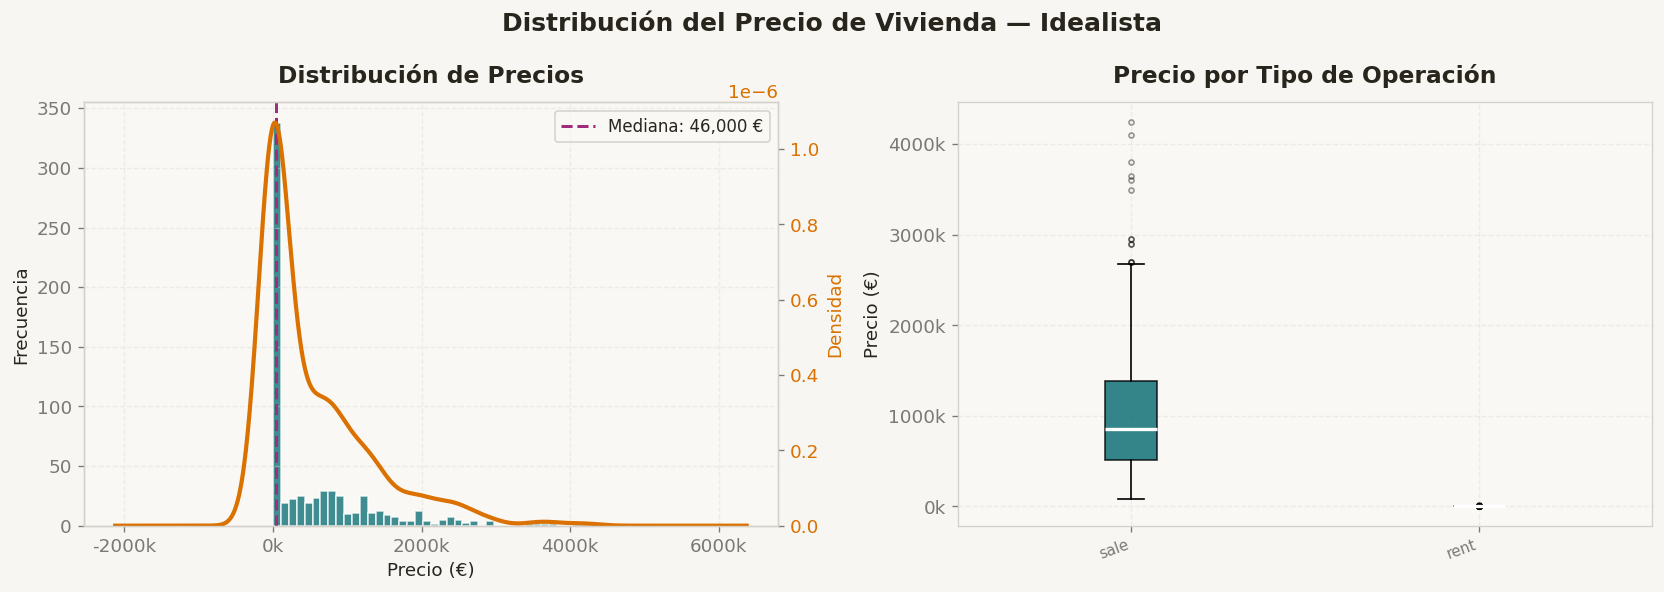

✅ viz1_distribucion_precios.png


In [6]:
#============================================
# Celda 3 — VIZ 1: Distribución del precio
#============================================
p_col = col_precio[0]
df_p  = df[df[p_col].between(df[p_col].quantile(0.01), df[p_col].quantile(0.99))].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución del Precio de Vivienda — Idealista', fontsize=15, fontweight='bold')

ax = axes[0]
ax.hist(df_p[p_col], bins=40, color=TEAL, alpha=0.75, edgecolor='white')
ax2 = ax.twinx()
df_p[p_col].plot.kde(ax=ax2, color=ORANGE, linewidth=2.5)
ax2.set_ylabel('Densidad', color=ORANGE); ax2.tick_params(axis='y', labelcolor=ORANGE); ax2.set_ylim(bottom=0)
mediana = df_p[p_col].median()
ax.axvline(mediana, color=RED, linestyle='--', lw=1.8, label=f'Mediana: {mediana:,.0f} €')
ax.legend(fontsize=10); ax.set_xlabel('Precio (€)'); ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Precios'); ax.grid(True, alpha=0.4)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))

ax = axes[1]
if col_type:
    t_col = col_type[0]
    tipos = df_p[t_col].value_counts().index[:5]
    data_box = [df_p[df_p[t_col]==t][p_col].dropna().values for t in tipos]
    bp = ax.boxplot(data_box, patch_artist=True, medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4, color=TEAL))
    for patch, color in zip(bp['boxes'], PALETTE): patch.set_facecolor(color); patch.set_alpha(0.8)
    ax.set_xticklabels(tipos, rotation=20, ha='right', fontsize=9)
ax.set_title('Precio por Tipo de Operación'); ax.set_ylabel('Precio (€)'); ax.grid(True, alpha=0.4)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))

plt.tight_layout()
fig.savefig(OUT / 'viz1_distribucion_precios.png', dpi=130, bbox_inches='tight')
plt.show(); print('✅ viz1_distribucion_precios.png')

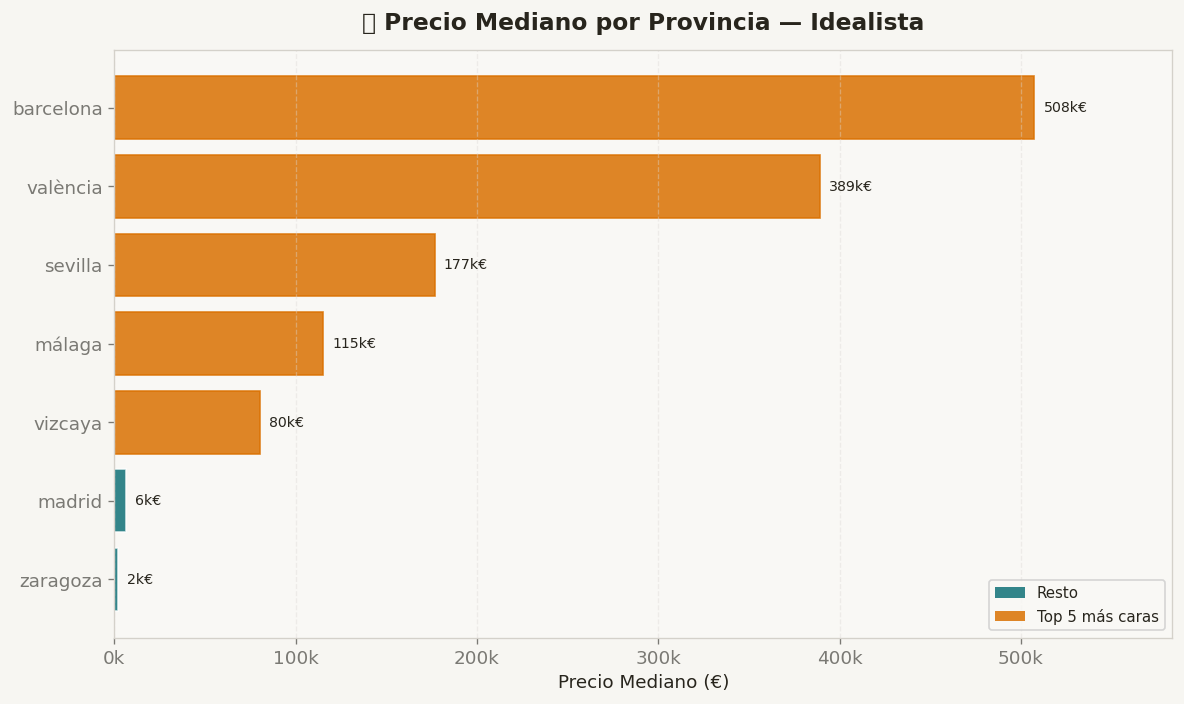

✅ viz2_precio_por_provincia.png


In [7]:
#============================================
# Celda 4 — VIZ 2: Precio medio por provincia
#============================================
p_col = col_precio[0]; prov_col = col_prov[0]

precio_prov = (
    df.groupby(prov_col)[p_col].agg(precio_medio='median', n='count')
    .reset_index().query('n >= 3').sort_values('precio_medio', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, max(6, len(precio_prov)*0.38)))
bars = ax.barh(precio_prov[prov_col], precio_prov['precio_medio'], color=TEAL, alpha=0.80, edgecolor='white')

top5_idx = precio_prov['precio_medio'].nlargest(5).index
for idx, bar in zip(precio_prov.index, bars):
    if idx in top5_idx: bar.set_color(ORANGE); bar.set_alpha(0.85)
    ax.text(bar.get_width() + precio_prov['precio_medio'].max()*0.01,
            bar.get_y()+bar.get_height()/2, f'{bar.get_width()/1000:.0f}k€',
            va='center', ha='left', fontsize=8.5)

ax.set_xlabel('Precio Mediano (€)'); ax.set_title('💰 Precio Mediano por Provincia — Idealista')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
ax.set_xlim(right=precio_prov['precio_medio'].max()*1.15); ax.grid(True, axis='x', alpha=0.4)
ax.legend(handles=[Patch(facecolor=TEAL,alpha=0.8,label='Resto'),
                   Patch(facecolor=ORANGE,alpha=0.85,label='Top 5 más caras')], loc='lower right', fontsize=9)

plt.tight_layout()
fig.savefig(OUT / 'viz2_precio_por_provincia.png', dpi=130, bbox_inches='tight')
plt.show(); print('✅ viz2_precio_por_provincia.png')

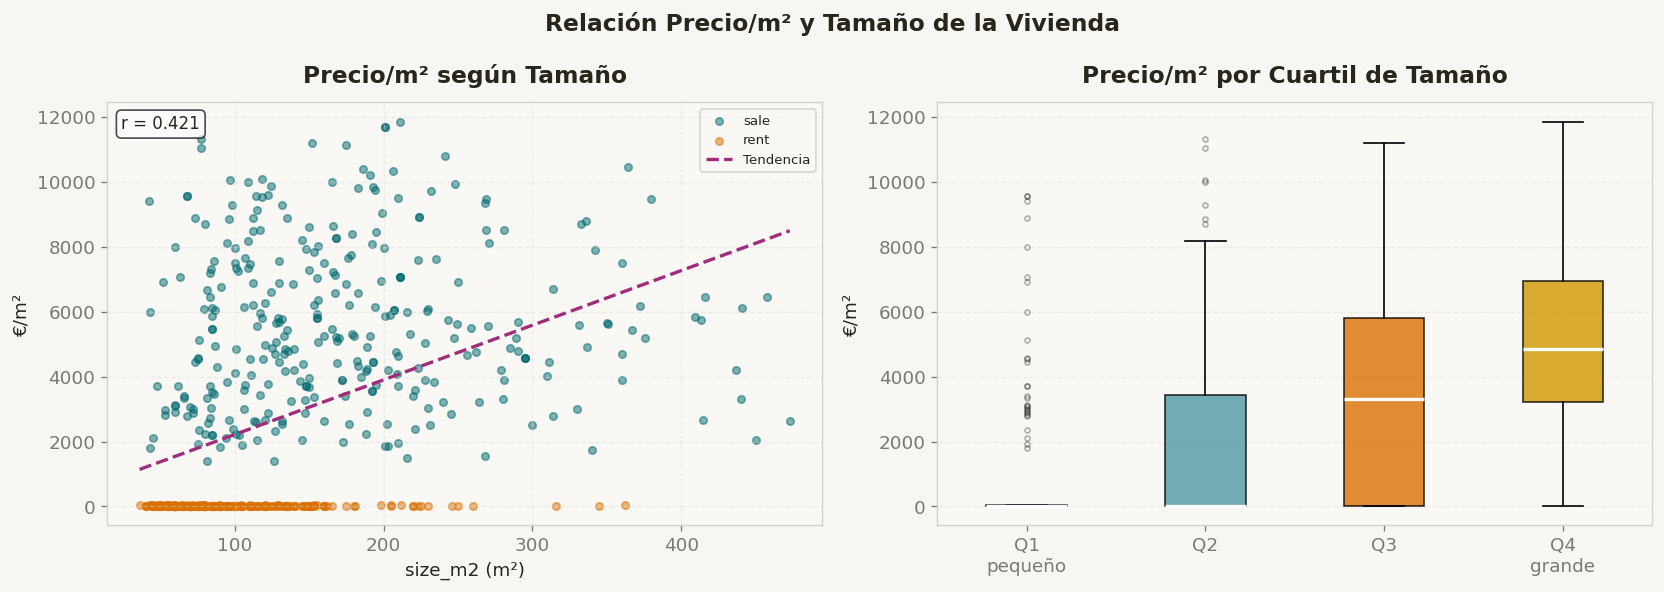

✅ viz3_precio_m2_vs_tamanio.png


In [8]:
#============================================
# Celda 5 — VIZ 3: Precio/m² vs Tamaño
#============================================
p_col = col_precio[0]; s_col = col_size[0]

df_sc = df[
    df['precio_m2'].between(df['precio_m2'].quantile(0.02), df['precio_m2'].quantile(0.98)) &
    df[s_col].between(df[s_col].quantile(0.02), df[s_col].quantile(0.98))
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Relación Precio/m² y Tamaño de la Vivienda', fontsize=14, fontweight='bold')

ax = axes[0]
if col_type:
    t_col = col_type[0]
    for i, tipo in enumerate(df_sc[t_col].value_counts().index[:5]):
        mask = df_sc[t_col]==tipo
        ax.scatter(df_sc.loc[mask,s_col], df_sc.loc[mask,'precio_m2'], color=PALETTE[i], alpha=0.5, s=20, label=tipo)
    ax.legend(fontsize=8, title='Tipo')
else:
    ax.scatter(df_sc[s_col], df_sc['precio_m2'], color=TEAL, alpha=0.5, s=20)

z = np.polyfit(df_sc[s_col].dropna(), df_sc['precio_m2'].dropna(), 1)
x_line = np.linspace(df_sc[s_col].min(), df_sc[s_col].max(), 200)
ax.plot(x_line, np.poly1d(z)(x_line), '--', color=RED, lw=2, label='Tendencia'); ax.legend(fontsize=8)
corr = df_sc[[s_col,'precio_m2']].corr().iloc[0,1]
ax.text(0.02,0.97,f'r = {corr:.3f}',transform=ax.transAxes,fontsize=10,va='top',
        bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.7))
ax.set_xlabel(f'{s_col} (m²)'); ax.set_ylabel('€/m²'); ax.set_title('Precio/m² según Tamaño'); ax.grid(True,alpha=0.4)

ax = axes[1]
df_sc['cuartil'] = pd.qcut(df_sc[s_col],4,labels=['Q1 pequeño','Q2','Q3','Q4 grande'])
bp_data = [df_sc[df_sc['cuartil']==q]['precio_m2'].dropna().values for q in ['Q1 pequeño','Q2','Q3','Q4 grande']]
bp = ax.boxplot(bp_data, patch_artist=True, medianprops=dict(color='white',lw=2),
                flierprops=dict(marker='o',markersize=3,alpha=0.3,color=TEAL))
for patch,color in zip(bp['boxes'],[TEAL,TEAL2,ORANGE,GOLD]): patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_xticklabels(['Q1\npequeño','Q2','Q3','Q4\ngrande'])
ax.set_title('Precio/m² por Cuartil de Tamaño'); ax.set_ylabel('€/m²'); ax.grid(True,axis='y',alpha=0.4)

plt.tight_layout()
fig.savefig(OUT/'viz3_precio_m2_vs_tamanio.png',dpi=130,bbox_inches='tight')
plt.show(); print('✅ viz3_precio_m2_vs_tamanio.png')

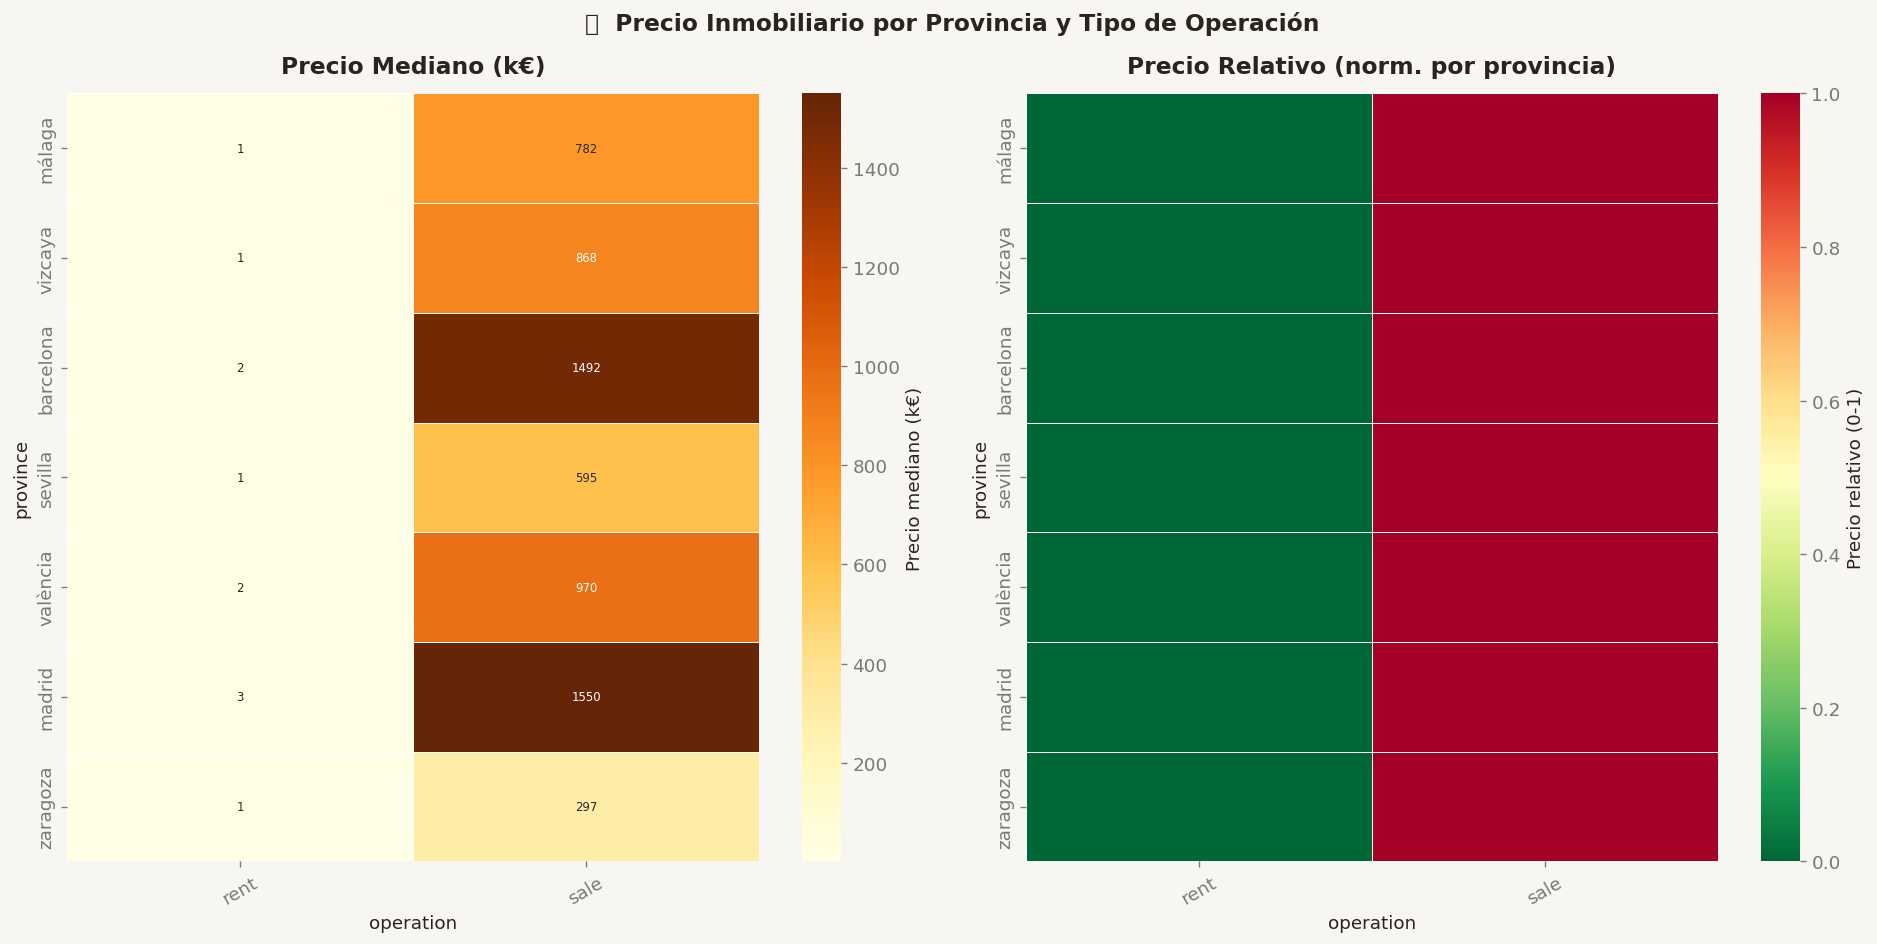

✅ viz4_heatmap_provincia_tipo.png


In [9]:
#============================================
# Celda 6 — VIZ 4: Heatmap provincia × tipo
#============================================
p_col=col_precio[0]; prov_col=col_prov[0]; tipo_col=col_type[0]

pivot = df.groupby([prov_col,tipo_col])[p_col].median().unstack(fill_value=np.nan)
top_provs = df.groupby(prov_col).size().nlargest(20).index
pivot = pivot.reindex([p for p in top_provs if p in pivot.index])
pivot_norm = pivot.div(pivot.max(axis=1), axis=0)

fig, axes = plt.subplots(1,2,figsize=(16,8))
fig.suptitle('🗺️  Precio Inmobiliario por Provincia y Tipo de Operación', fontsize=14, fontweight='bold')

sns.heatmap(pivot/1000, ax=axes[0], cmap='YlOrBr', linewidths=0.3, annot=True, fmt='.0f',
            cbar_kws={'label':'Precio mediano (k€)'}, annot_kws={'size':7})
axes[0].set_title('Precio Mediano (k€)'); axes[0].tick_params(axis='x',rotation=30)

sns.heatmap(pivot_norm, ax=axes[1], cmap='RdYlGn_r', linewidths=0.3, vmin=0, vmax=1,
            cbar_kws={'label':'Precio relativo (0-1)'})
axes[1].set_title('Precio Relativo (norm. por provincia)'); axes[1].tick_params(axis='x',rotation=30)

plt.tight_layout()
fig.savefig(OUT/'viz4_heatmap_provincia_tipo.png',dpi=130,bbox_inches='tight')
plt.show(); print('✅ viz4_heatmap_provincia_tipo.png')

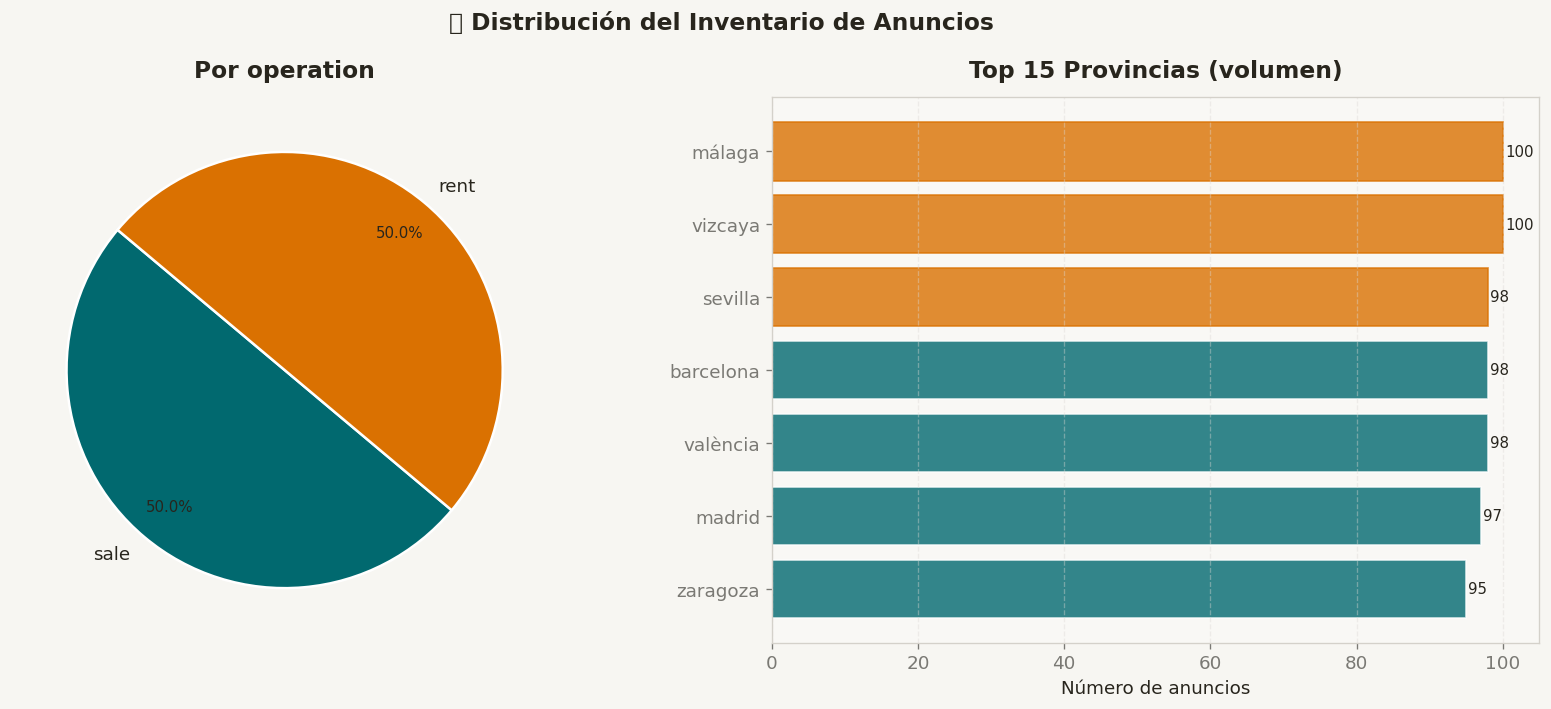

✅ viz5_distribucion_anuncios.png


In [10]:
#============================================
# Celda 7 — VIZ 5: Distribución de anuncios
#============================================
prov_col=col_prov[0]; t_col=col_type[0]

fig, axes = plt.subplots(1,2,figsize=(14,6))
fig.suptitle('📊 Distribución del Inventario de Anuncios', fontsize=14, fontweight='bold')

ax=axes[0]
counts_tipo=df[t_col].value_counts().head(6)
wedges,texts,autotexts=ax.pie(counts_tipo,labels=counts_tipo.index,autopct='%1.1f%%',
    colors=PALETTE[:len(counts_tipo)],startangle=140,pctdistance=0.82,
    wedgeprops=dict(linewidth=1.5,edgecolor='white'))
for at in autotexts: at.set_fontsize(9)
ax.set_title(f'Por {t_col}')

ax=axes[1]
counts_prov=df[prov_col].value_counts().head(15).sort_values()
bars=ax.barh(counts_prov.index,counts_prov.values,color=TEAL,alpha=0.8,edgecolor='white')
for i,(bar,val) in enumerate(zip(bars,counts_prov.values)):
    if i>=len(counts_prov)-3: bar.set_color(ORANGE)
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2, str(val), va='center', fontsize=9)
ax.set_xlabel('Número de anuncios'); ax.set_title('Top 15 Provincias (volumen)'); ax.grid(True,axis='x',alpha=0.4)

plt.tight_layout()
fig.savefig(OUT/'viz5_distribucion_anuncios.png',dpi=130,bbox_inches='tight')
plt.show(); print('✅ viz5_distribucion_anuncios.png')

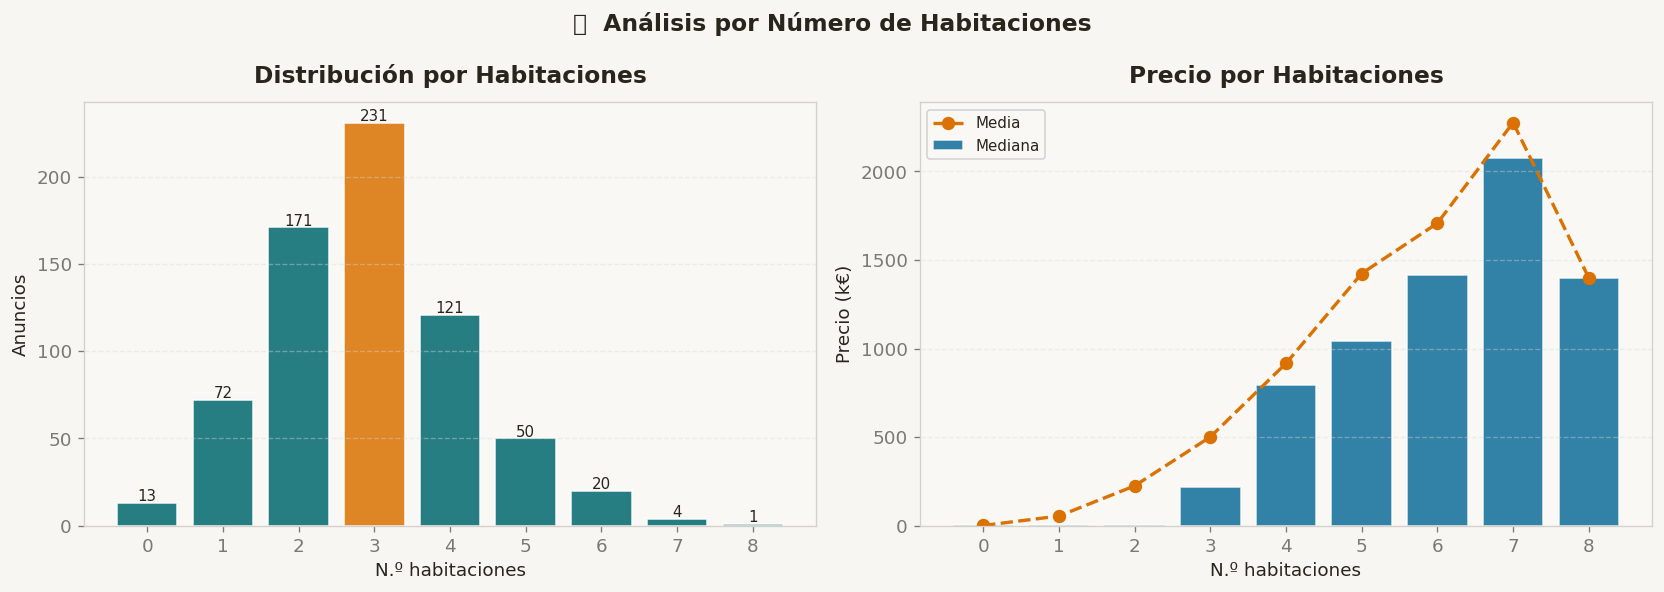

✅ viz6_habitaciones_precio.png


In [11]:
#============================================
# Celda 8 — VIZ 6: Habitaciones y precio
#============================================
r_col=col_rooms[0]; p_col=col_precio[0]

fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle(f'🛏️  Análisis por Número de Habitaciones', fontsize=14, fontweight='bold')

ax=axes[0]
rooms_count=df[r_col].value_counts().sort_index()
try: rooms_count=rooms_count[rooms_count.index.astype(float)<=8]
except: rooms_count=rooms_count.head(8)
ax.bar(rooms_count.index.astype(str),rooms_count.values,
       color=[ORANGE if i==rooms_count.values.argmax() else TEAL for i in range(len(rooms_count))],
       alpha=0.85,edgecolor='white')
for i,(x,v) in enumerate(zip(rooms_count.index.astype(str),rooms_count.values)):
    ax.text(i,v+1,str(v),ha='center',fontsize=9)
ax.set_xlabel('N.º habitaciones'); ax.set_ylabel('Anuncios'); ax.set_title('Distribución por Habitaciones'); ax.grid(True,axis='y',alpha=0.4)

ax=axes[1]
df_tmp=df[df[r_col].astype(str).str.match(r'^[\d\.]+$')].copy()
df_tmp['hab_num']=df_tmp[r_col].astype(float).astype(int)
pr=df_tmp.query('hab_num<=8').groupby('hab_num')[p_col].agg(['median','mean','count']).reset_index()
ax.bar(pr['hab_num'].astype(str),pr['median']/1000,color=BLUE,alpha=0.8,label='Mediana',edgecolor='white')
ax.plot(range(len(pr)),pr['mean']/1000,'o--',color=ORANGE,lw=2,markersize=7,label='Media')
ax.set_xlabel('N.º habitaciones'); ax.set_ylabel('Precio (k€)'); ax.set_title('Precio por Habitaciones')
ax.legend(fontsize=9); ax.grid(True,axis='y',alpha=0.4)

plt.tight_layout()
fig.savefig(OUT/'viz6_habitaciones_precio.png',dpi=130,bbox_inches='tight')
plt.show(); print('✅ viz6_habitaciones_precio.png')

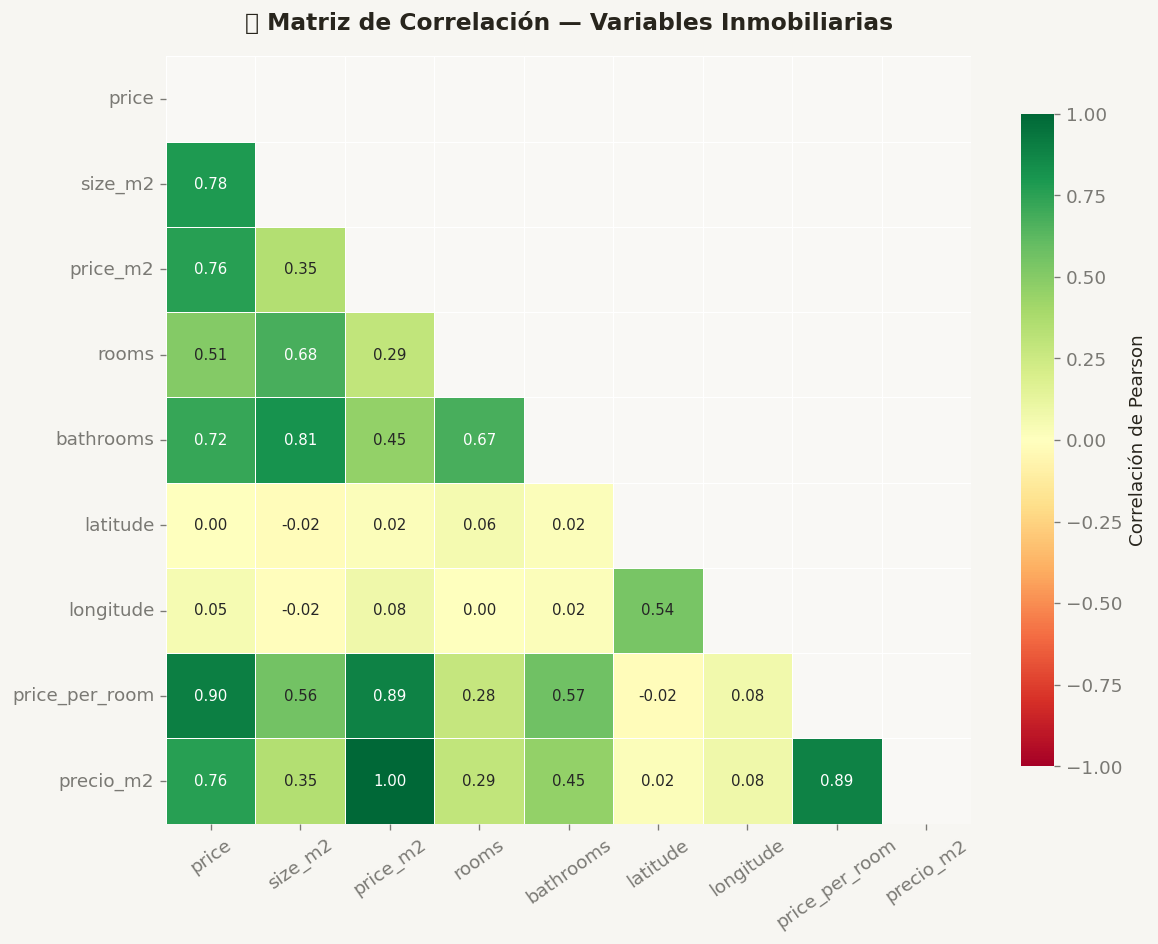

✅ viz7_correlacion.png


In [12]:
#============================================
# Celda 9 — VIZ 7: Matriz de correlación
#============================================
num_df=df.select_dtypes(include='number').loc[:,df.select_dtypes(include='number').isna().mean()<0.70]
keywords=['price','size','room','floor','lat','lon','bath','precio','metros','hab']
cols=[c for c in num_df.columns if any(k in c.lower() for k in keywords)]
if 'precio_m2' in num_df.columns: cols.append('precio_m2')
cols=list(dict.fromkeys(cols))[:12]

corr_matrix=num_df[cols].corr()
mask=np.triu(np.ones_like(corr_matrix,dtype=bool))

fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr_matrix,mask=mask,ax=ax,cmap='RdYlGn',vmin=-1,vmax=1,
            annot=True,fmt='.2f',annot_kws={'size':9},linewidths=0.5,
            cbar_kws={'label':'Correlación de Pearson','shrink':0.85})
ax.set_title('🔗 Matriz de Correlación — Variables Inmobiliarias', fontsize=14, fontweight='bold', pad=16)
ax.tick_params(axis='x',rotation=35); ax.tick_params(axis='y',rotation=0)

plt.tight_layout()
fig.savefig(OUT/'viz7_correlacion.png',dpi=130,bbox_inches='tight')
plt.show(); print('✅ viz7_correlacion.png')

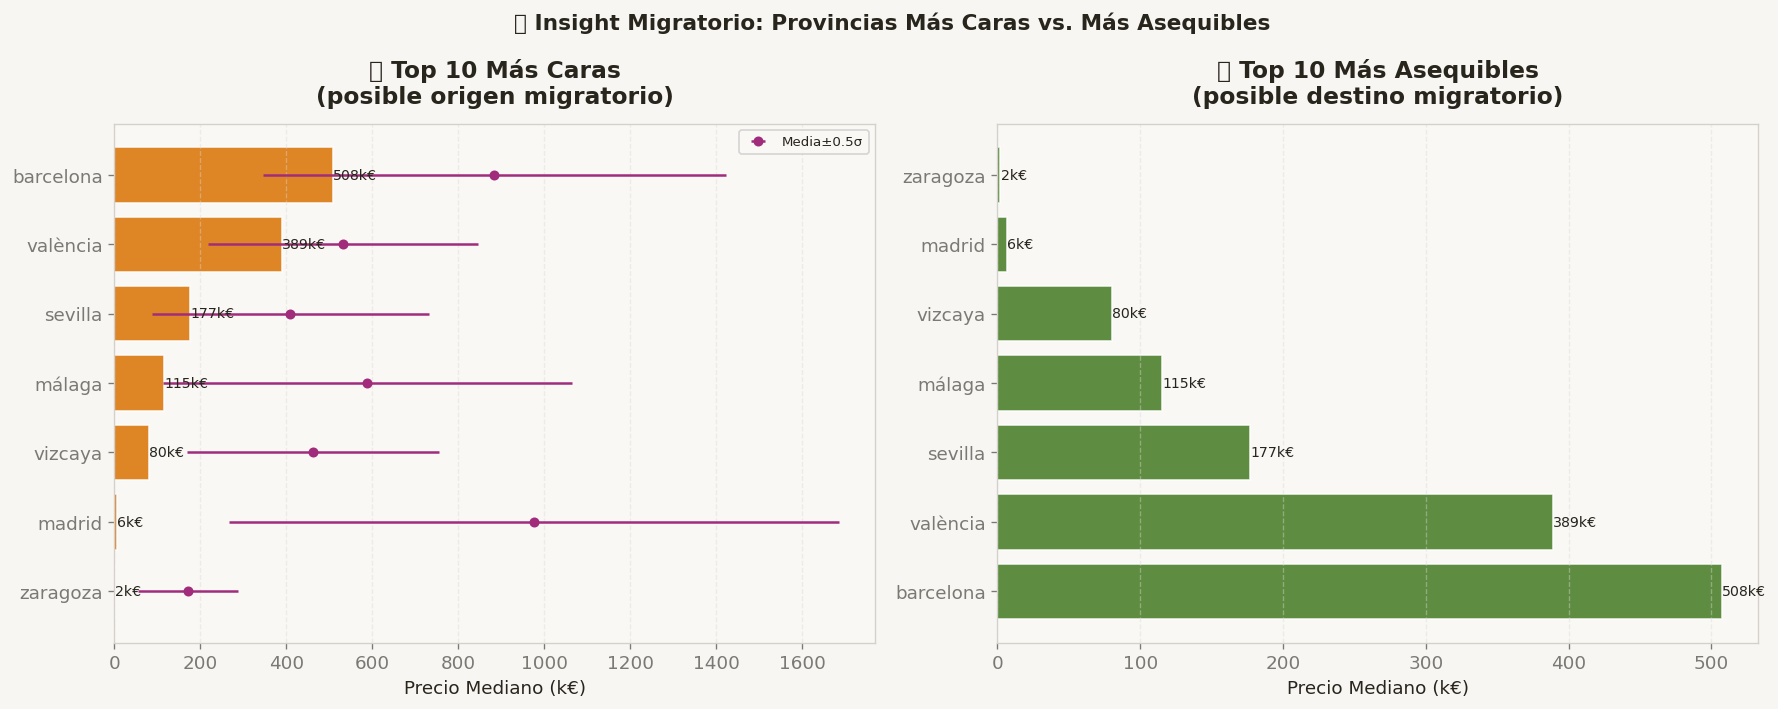

✅ viz8 + insights_precio_provincia.csv


In [13]:
#============================================
# Celda 10 — VIZ 8: Insight migratorio
#            Top 10 caras vs asequibles
#============================================
p_col=col_precio[0]; prov_col=col_prov[0]

stats=df.groupby(prov_col)[p_col].agg(mediana='median',media='mean',n='count',std='std').reset_index().query('n>=5')
top10_caras=stats.nlargest(10,'mediana').sort_values('mediana')
top10_baratas=stats.nsmallest(10,'mediana').sort_values('mediana',ascending=False)

fig, axes = plt.subplots(1,2,figsize=(15,6))
fig.suptitle('🔍 Insight Migratorio: Provincias Más Caras vs. Más Asequibles', fontsize=13, fontweight='bold')

ax=axes[0]
bars=ax.barh(top10_caras[prov_col],top10_caras['mediana']/1000,color=ORANGE,alpha=0.85,edgecolor='white')
ax.errorbar(top10_caras['media']/1000,range(len(top10_caras)),
            xerr=top10_caras['std']/1000*0.5,fmt='o',color=RED,markersize=5,lw=1.5,label='Media±0.5σ')
for bar in bars:
    ax.text(bar.get_width()+0.5,bar.get_y()+bar.get_height()/2,f'{bar.get_width():.0f}k€',va='center',fontsize=8.5)
ax.set_xlabel('Precio Mediano (k€)'); ax.legend(fontsize=8); ax.grid(True,axis='x',alpha=0.4)
ax.set_title('🔴 Top 10 Más Caras\n(posible origen migratorio)')

ax=axes[1]
bars=ax.barh(top10_baratas[prov_col],top10_baratas['mediana']/1000,color=GREEN,alpha=0.85,edgecolor='white')
for bar in bars:
    ax.text(bar.get_width()+0.3,bar.get_y()+bar.get_height()/2,f'{bar.get_width():.0f}k€',va='center',fontsize=8.5)
ax.set_xlabel('Precio Mediano (k€)'); ax.grid(True,axis='x',alpha=0.4)
ax.set_title('🟢 Top 10 Más Asequibles\n(posible destino migratorio)')

plt.tight_layout()
fig.savefig(OUT/'viz8_top10_caro_vs_barato.png',dpi=130,bbox_inches='tight')
stats.sort_values('mediana',ascending=False).to_csv(OUT/'insights_precio_provincia.csv',index=False)
plt.show(); print('✅ viz8 + insights_precio_provincia.csv')

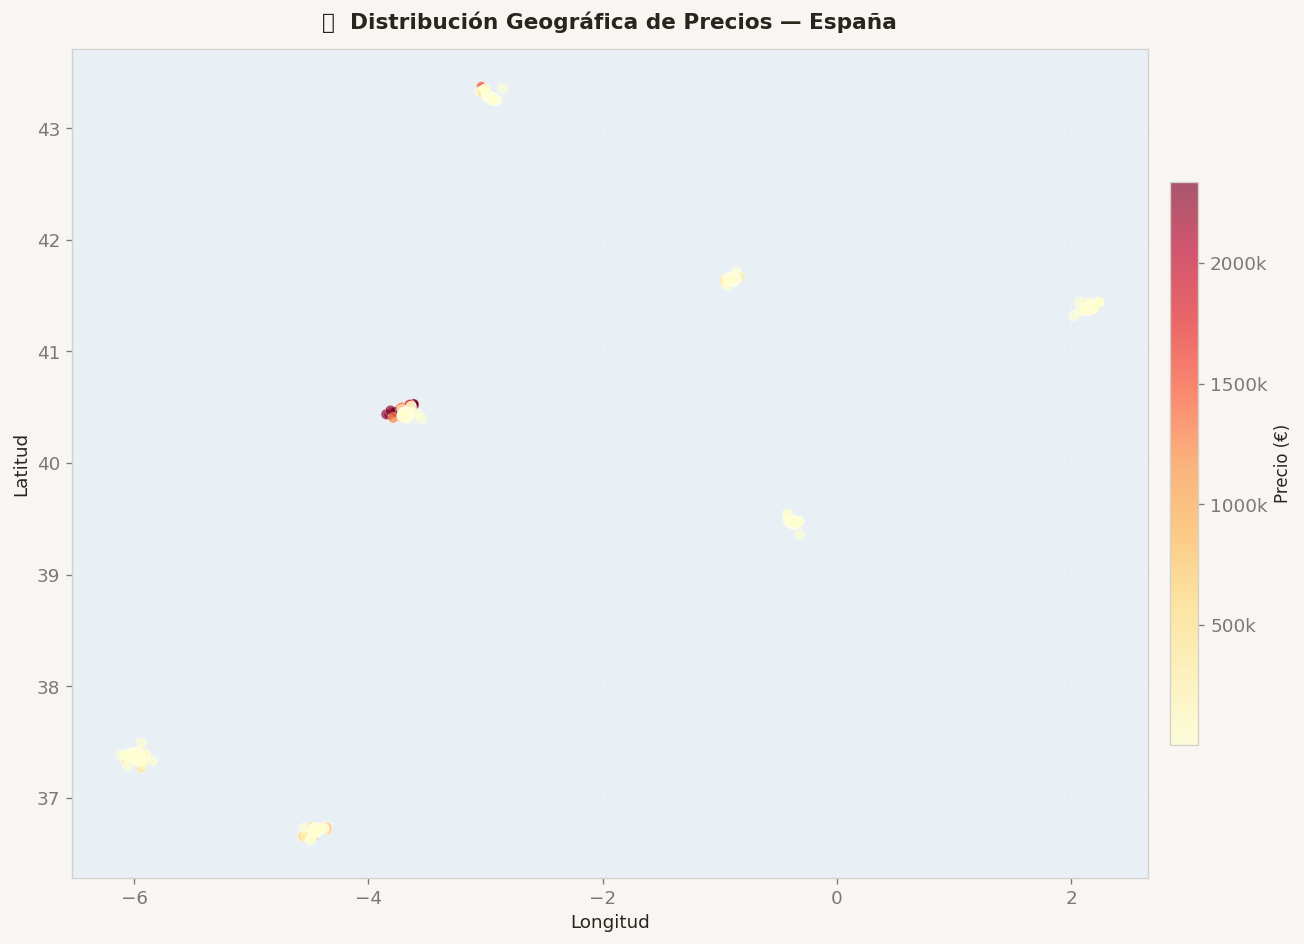

✅ viz9_mapa_geografico.png


In [14]:
#============================================
# Celda 11 — VIZ 9: Mapa geográfico lat/lon
#============================================
col_lat=[c for c in df.columns if 'lat' in c.lower()]
col_lon=[c for c in df.columns if 'lon' in c.lower() or 'lng' in c.lower()]
p_col=col_precio[0]

if col_lat and col_lon:
    lat_col=col_lat[0]; lon_col=col_lon[0]
    df_geo=df[[lat_col,lon_col,p_col]].dropna()
    df_geo=df_geo[df_geo[lat_col].between(35.5,44.0)&df_geo[lon_col].between(-9.5,4.5)]

    fig,ax=plt.subplots(figsize=(11,8))
    sc=ax.scatter(df_geo[lon_col],df_geo[lat_col],c=df_geo[p_col],cmap='YlOrRd',s=40,alpha=0.65,
                  edgecolors='white',linewidths=0.3,
                  norm=plt.Normalize(vmin=df_geo[p_col].quantile(0.05),vmax=df_geo[p_col].quantile(0.95)))
    cbar=plt.colorbar(sc,ax=ax,pad=0.02,fraction=0.025)
    cbar.set_label('Precio (€)',fontsize=10)
    cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
    ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
    ax.set_title('🗺️  Distribución Geográfica de Precios — España', fontsize=13, fontweight='bold')
    ax.set_facecolor('#E8EFF5'); ax.grid(True,alpha=0.3,color='white')
    plt.tight_layout()
    fig.savefig(OUT/'viz9_mapa_geografico.png',dpi=130,bbox_inches='tight')
    plt.show(); print('✅ viz9_mapa_geografico.png')
else:
    print(f'⚠️  Sin columnas lat/lon — disponibles: {list(df.columns)}')

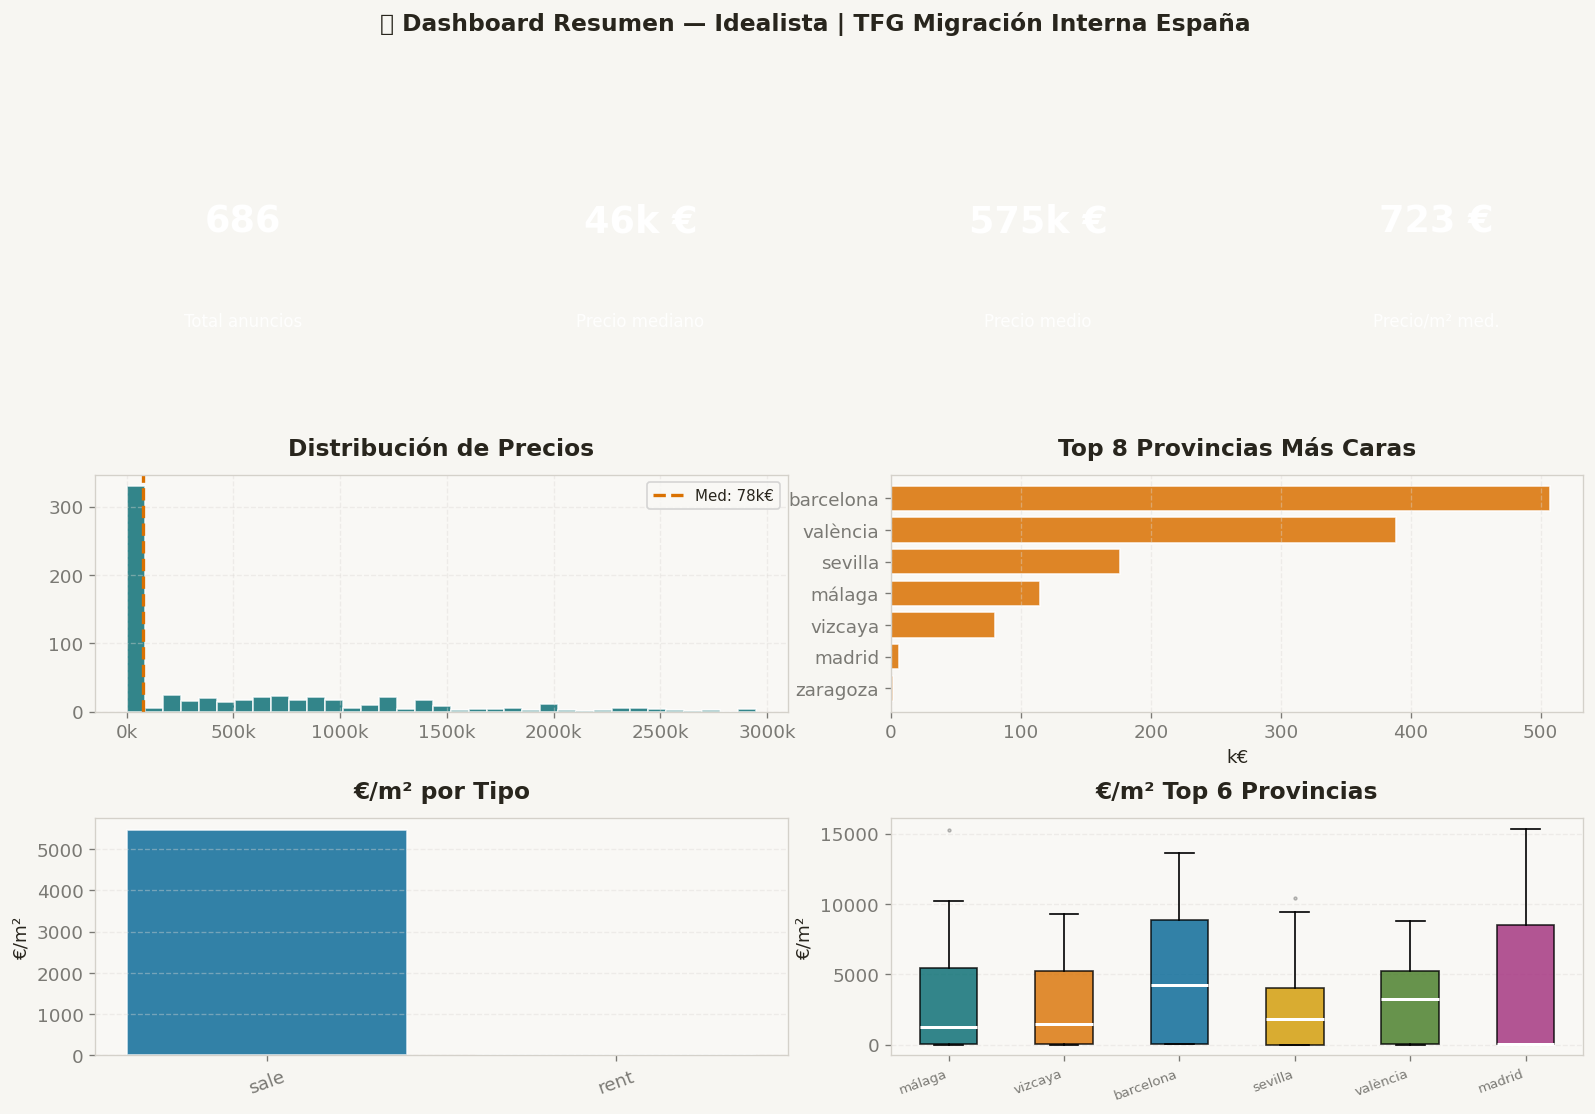

✅ viz10_dashboard_resumen.png


In [15]:
#============================================
# Celda 12 — VIZ 10: Dashboard KPI resumen
#============================================
p_col=col_precio[0]; prov_col=col_prov[0]; t_col=col_type[0]

fig=plt.figure(figsize=(16,10))
fig.suptitle('📊 Dashboard Resumen — Idealista | TFG Migración Interna España',fontsize=14,fontweight='bold',y=0.98)
gs=fig.add_gridspec(3,4,hspace=0.45,wspace=0.35)

kpis=[('Total anuncios',f'{len(df):,}',TEAL),
      ('Precio mediano',f'{df[p_col].median()/1000:.0f}k €',ORANGE),
      ('Precio medio',f'{df[p_col].mean()/1000:.0f}k €',BLUE),
      ('Precio/m² med.',f'{df["precio_m2"].median():.0f} €' if 'precio_m2' in df else 'N/A',GOLD)]
for i,(label,val,color) in enumerate(kpis):
    ax=fig.add_subplot(gs[0,i]); ax.set_facecolor(color)
    ax.text(0.5,0.62,val,ha='center',va='center',transform=ax.transAxes,fontsize=22,fontweight='bold',color='white')
    ax.text(0.5,0.2,label,ha='center',va='center',transform=ax.transAxes,fontsize=10,color='white',alpha=0.9)
    ax.axis('off')

ax1=fig.add_subplot(gs[1,:2])
df_p=df[df[p_col].between(df[p_col].quantile(0.02),df[p_col].quantile(0.98))]
ax1.hist(df_p[p_col],bins=35,color=TEAL,alpha=0.8,edgecolor='white')
ax1.axvline(df_p[p_col].median(),color=ORANGE,linestyle='--',lw=2,label=f'Med: {df_p[p_col].median()/1000:.0f}k€')
ax1.set_title('Distribución de Precios'); ax1.legend(fontsize=9); ax1.grid(True,alpha=0.4)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))

ax2=fig.add_subplot(gs[1,2:])
top8=df.groupby(prov_col)[p_col].median().nlargest(8).sort_values()
ax2.barh(top8.index,top8.values/1000,color=ORANGE,alpha=0.85,edgecolor='white')
ax2.set_title('Top 8 Provincias Más Caras'); ax2.set_xlabel('k€'); ax2.grid(True,axis='x',alpha=0.4)

ax3=fig.add_subplot(gs[2,:2])
if 'precio_m2' in df.columns:
    pm2=df.groupby(t_col)['precio_m2'].median().sort_values(ascending=False).head(6)
    ax3.bar(pm2.index,pm2.values,color=BLUE,alpha=0.8,edgecolor='white')
    ax3.set_title('€/m² por Tipo'); ax3.set_ylabel('€/m²'); ax3.tick_params(axis='x',rotation=20); ax3.grid(True,axis='y',alpha=0.4)

ax4=fig.add_subplot(gs[2,2:])
top6=df.groupby(prov_col).size().nlargest(6).index
bp_data=[df[df[prov_col]==p]['precio_m2'].dropna().values for p in top6]
bp=ax4.boxplot(bp_data,patch_artist=True,medianprops=dict(color='white',lw=1.8),
               flierprops=dict(marker='.',markersize=3,alpha=0.3))
for patch,color in zip(bp['boxes'],PALETTE[:6]): patch.set_facecolor(color); patch.set_alpha(0.8)
ax4.set_xticklabels([str(p)[:10] for p in top6],rotation=20,ha='right',fontsize=8)
ax4.set_title('€/m² Top 6 Provincias'); ax4.set_ylabel('€/m²'); ax4.grid(True,axis='y',alpha=0.4)

fig.savefig(OUT/'viz10_dashboard_resumen.png',dpi=140,bbox_inches='tight')
plt.show(); print('✅ viz10_dashboard_resumen.png')

In [16]:
#============================================
# Celda 13 — Conclusiones e insights TFG
#============================================
p_col=col_precio[0]; prov_col=col_prov[0]; tipo_col=col_type[0]

print('='*65)
print('  📋 INSIGHTS Y CONCLUSIONES — ANÁLISIS IDEALISTA')
print('='*65)
print(f'\n🔢 ESTADÍSTICAS GENERALES')
print(f'   Total anuncios  : {len(df):,}')
print(f'   Precio mediano  : {df[p_col].median():,.0f} €')
print(f'   Precio medio    : {df[p_col].mean():,.0f} €')
print(f'   Desv. estándar  : {df[p_col].std():,.0f} €')
if 'precio_m2' in df.columns: print(f'   Precio/m² med.  : {df["precio_m2"].median():,.0f} €/m²')

stats=df.groupby(prov_col)[p_col].median()
print(f'\n🗺️  POLARIZACIÓN GEOGRÁFICA')
print(f'   Provincia más cara       : {stats.idxmax()} — {stats.max():,.0f} €')
print(f'   Provincia más asequible  : {stats.idxmin()} — {stats.min():,.0f} €')
print(f'   Ratio caro/barato        : {stats.max()/stats.min():.1f}x')

tipo_counts=df[tipo_col].value_counts()
tipo_precio=df.groupby(tipo_col)[p_col].median().sort_values(ascending=False)
print(f'\n🏠 TIPOLOGÍA DE OPERACIÓN')
for t,v in tipo_counts.head(4).items():
    print(f'   {t:<20} {v:4d} anuncios ({v/len(df)*100:.1f}%) — Mediana: {tipo_precio.get(t,0):,.0f} €')

if col_size and 'precio_m2' in df.columns:
    s_col=col_size[0]
    print(f'\n🔗 CORRELACIONES CLAVE')
    print(f'   Tamaño ↔ Precio total : r = {df[[s_col,p_col]].corr().iloc[0,1]:.3f}')
    print(f'   Tamaño ↔ Precio/m²   : r = {df[[s_col,"precio_m2"]].corr().iloc[0,1]:.3f}')

print(f'\n🎯 RECOMENDACIONES MODELO PREDICTIVO (TFG)')
print('   ✓ Usar precio_m2 mediano por provincia como variable explicativa')
print('   ✓ Ratio caro/barato → indicador de tensión migratoria')
print('   ✓ Segmentar por tipo (venta vs. alquiler) en el merge con EVR/INE')
print('   ✓ precio_m2 más robusto que precio total para el modelo')
print(f'\n✅ Pipeline 03_idealista completado — {len(list(OUT.glob("*.png")))} visualizaciones')

  📋 INSIGHTS Y CONCLUSIONES — ANÁLISIS IDEALISTA

🔢 ESTADÍSTICAS GENERALES
   Total anuncios  : 686
   Precio mediano  : 46,000 €
   Precio medio    : 575,192 €
   Desv. estándar  : 902,003 €
   Precio/m² med.  : 723 €/m²

🗺️  POLARIZACIÓN GEOGRÁFICA
   Provincia más cara       : barcelona — 507,500 €
   Provincia más asequible  : zaragoza — 1,949 €
   Ratio caro/barato        : 260.4x

🏠 TIPOLOGÍA DE OPERACIÓN
   sale                  343 anuncios (50.0%) — Mediana: 870,000 €
   rent                  343 anuncios (50.0%) — Mediana: 1,400 €

🔗 CORRELACIONES CLAVE
   Tamaño ↔ Precio total : r = 0.782
   Tamaño ↔ Precio/m²   : r = 0.350

🎯 RECOMENDACIONES MODELO PREDICTIVO (TFG)
   ✓ Usar precio_m2 mediano por provincia como variable explicativa
   ✓ Ratio caro/barato → indicador de tensión migratoria
   ✓ Segmentar por tipo (venta vs. alquiler) en el merge con EVR/INE
   ✓ precio_m2 más robusto que precio total para el modelo

✅ Pipeline 03_idealista completado — 10 visualizaciones
